In [1]:
## Deep Agent, the top layer

In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools import GoogleSerperRun
from langchain_community.utilities import GoogleSerperAPIWrapper
from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend

load_dotenv(override=True)

/tmp/ipykernel_1679/131892216.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import GoogleSerperRun


True

In [2]:
search = GoogleSerperRun(api_wrapper=GoogleSerperAPIWrapper())

In [3]:
sandbox = os.path.abspath("sandbox")
os.makedirs(sandbox, exist_ok=True)
model = ChatOpenAI(model="gpt-4.1-nano")

researcher = create_deep_agent(
    model = model,
    tools = [search],
    system_prompt=(
        "You are a research analyst. Plan your work with your to do tool, "
        "research with the search tool, and write your findings as a tidy markdown briefing to a fila file."
    ),
    backend=FilesystemBackend(root_dir=sandbox, virtual_mode=True),
)

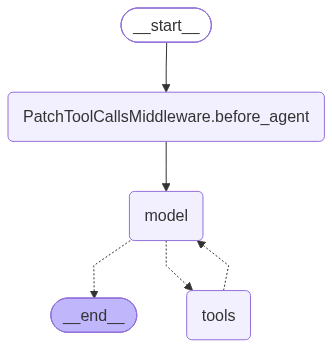

In [4]:
researcher

In [5]:
brief = """
Our company is planning to move its sales fleet to electric vehicles.
Research the public EV charging landscape in the US: find out roughly how many public charging points there are,
and pick out two major charging networks a fleet could rely on.
Write a one page markdown briefing, with a heading and a short section for each, to the file charging.md.
"""

result = researcher.invoke({
    "messages": [{
        "role": "user",
        "content": brief
    }]
})

print(result["messages"][-1].content)

# Electric Vehicle Charging Landscape in the US

## Overview of Public EV Charging Points
The federal government reports that, as of September, there are more than 228,000 EV charging ports at approximately 76,000 locations across the United States. This extensive network helps support the growing adoption of electric vehicles and is expected to expand further as infrastructure investments continue.

## Major EV Charging Networks
Two of the leading charging networks that a fleet could rely on are:

### Electrify America
- A prominent and rapidly expanding network of fast chargers across the US.
- Offers widespread coverage with numerous fast charging stations.
- Known for reliability and speed, making it suitable for fleet operations.

### ChargePoint
- One of the largest and most trusted EV charging networks in the US.
- Provides a broad network of stations accessible via an easy-to-use app.
- Suitable for both urban and suburban fleet charging needs due to its extensive presence.

Th

In [7]:
tool_used = [tc["name"] for m in result["messages"] for tc in (getattr(m, "tool_calls", []))]
print("Tools the agnet called, in order:")
print(tool_used)

Tools the agnet called, in order:
['google_serper', 'glob', 'read_file']


In [10]:
research_ev_instructions = """
You research one electric vehicle using the search tool and return three concise facts
that a fleet buyer would care about, such as price, range and charging.
"""

overall_instructions = """
You write comparison briefings for a company choosing electric vehicles for its sales fleet.
For each vehicle, delegate the research to your vehicle-researcher sub-agent,
then write a markdown comparison to a file, ending with a clear recommendation.
"""

research_subagent = {
    "name": "vehicle-researcher",
    "description": "Researches a single electric vehicle and returns a short list of facts about it.",
    "system_prompt": research_ev_instructions,
}

lead = create_deep_agent(
    model = model,
    tools=[search],
    system_prompt = overall_instructions,
    subagents=[research_subagent],
    backend=FilesystemBackend(root_dir=sandbox, virtual_mode=True)
)

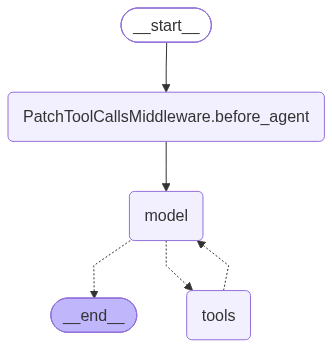

In [11]:
lead

In [12]:
mission = """
Compare the Tesla Model Y and the Ford Mustang Mach-E as candidates for our 100-car sales fleet.
Research each vehicle, then write a short markdown comparison with a recommendation to fleet.md.
"""

result = lead.invoke({"messages": [{"role": "user", "content": mission}]})

In [14]:
result["messages"][-1].content

'The comparison of the Tesla Model Y and the Ford Mustang Mach-E for the sales fleet has been completed and saved in the file `fleet.md`. Would you like to review or update this comparison?'

In [15]:
tools_used = [tc["name"] for m in result["messages"] for tc in (getattr(m, "tool_calls", []) or [])]
print("Tools the lead agent called:", tools_used)

Tools the lead agent called: ['task', 'task', 'write_file']


In [29]:
from langchain_core.tools import tool
from slide_kit import build_slide

@tool
def create_slide(title: str, key_points: list[str], recommendation: str) -> str:
    """create a one-slide powerpoint in the voltway research house style, saved as fleet.pptx"""
    build_slide(title, key_points, recommendation, os.path.join(sandbox, "fleet.pptx"))
    return "Saved the slide to /fleet.pptx"

slide_maker = {
    "name": "slide-maker",
    "description": "Turns a finished recommendation into a one-slide PowerPoint deck.",
    "system_prompt": "You turn research recommendations into slides, following your fleet-slide skill",
    "tools": [create_slide],
    "skills": ["/skills/"],
}

presenter = create_deep_agent(
    model=model,
    subagents=[slide_maker],
    system_prompt="You prepare research for presentation by delegating to your slide-maker sub-agent.",
    backend=FilesystemBackend(root_dir=sandbox, virtual_mode=True),
)

In [31]:
result = presenter.invoke({
    "messages": [{
        "role": "user",
        "content": "Read fleet.md and have a one-slide deck made of its recommendation."
    }]
})

print(result["messages"][-1].content)

The slide has been created with the key recommendations summarized from the fleet.md document. Would you like to download the slide or need any further modifications?


In [32]:
result = presenter.invoke({"messages": [{"role": "user", "content":
    "Read fleet.md and have a one-slide deck made of its recommendation."}]})
print(result["messages"][-1].content)

No, that's all. Thank you.
